In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from utils import * 

In [25]:
from pathlib import Path
import pandas as pd
import numpy as np

base = Path("clean_tables")
PRIMARY_KEY = "RowKey"

# 1. Load feature tables
sql_df    = pd.read_csv(base / "sql_metrics.csv")
qiskit_df  = pd.read_csv(base / "qiskit_simulation.csv")
rdbms_df  = pd.read_csv(base / "rdbms_simulation.csv")

# 2. Merge feature tables first (numeric features)
feature_df = sql_df

# 3. FEATURES = numeric columns only (excluding PRIMARY_KEY)
FEATURES = feature_df.select_dtypes(include=[np.number]).columns.tolist()

# 4. Keep only memory_usage / execution_time columns
keep_suffixes = ["mb", "time_s"]
rdbms_cols = [PRIMARY_KEY] + [c for c in rdbms_df.columns if any(c.endswith(s) for s in keep_suffixes)]
rdbms_df = rdbms_df[rdbms_cols]

# 5. Merge feature_df with RDBMS columns to get final ML-ready df
df = feature_df.merge(rdbms_df, on=PRIMARY_KEY)

sim_cols = [c for c in rdbms_df.columns if c != PRIMARY_KEY]
df["at_least_one_sim"] = df[sim_cols].notna().any(axis=1)

print("Rows after filtering automatic simulation:", len(df))
print("Number of numeric feature columns:", len(FEATURES))
print("FEATURES sample:", FEATURES)


C:\Users\aadik\AppData\Local\Temp\ipykernel_25388\4118905196.py:10: DtypeWarning: Columns (40) have mixed types. Specify dtype option on import or set low_memory=False.
  qiskit_df  = pd.read_csv(base / "qiskit_simulation.csv")


Rows after filtering automatic simulation: 775
Number of numeric feature columns: 11
FEATURES sample: ['infinidata_quantum_sql_agg_func', 'infinidata_quantum_sql_and', 'num_subqueries', 'infinidata_quantum_sql_eq_pred', 'num_group_bys', 'infinidata_quantum_sql_num_join_occurrences', 'num_joins', 'infinidata_quantum_sql_num_unique_join_edges', 'infinidata_quantum_sql_order_by', 'infinidata_quantum_sql_select', 'num_where_clauses']


Best execution time counts:
best_time_method
sqlite    681
Name: count, dtype: int64

Best memory usage counts:
best_mem_method
sqlite    681
Name: count, dtype: int64


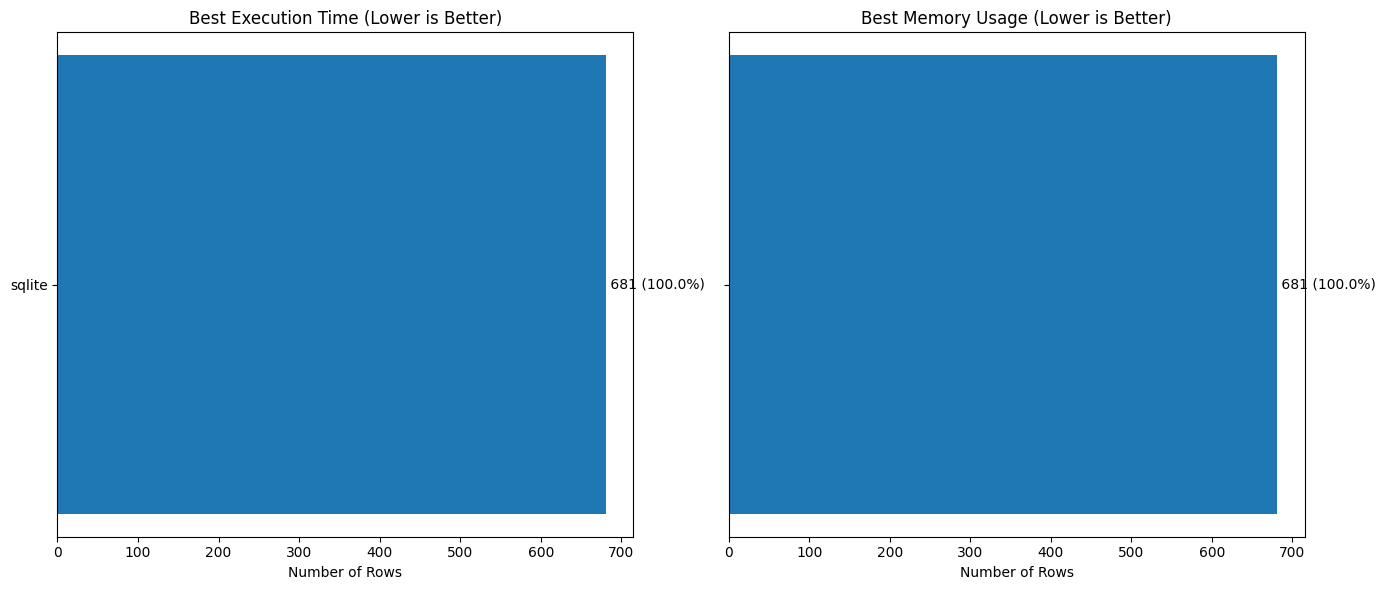

In [29]:
METHODS = [
    # "infiniquantum",
    # "psql",
    # "ducksql",
    "sqlite",
    # "np_mps",
    # "np_one_shot"
]
# These methods need to be in the column name to be that method. 

import matplotlib.pyplot as plt

# ----------------------------
# Identify metric columns
# ----------------------------
time_cols = {m: [c for c in df.columns if c.endswith("time_s") and m in c] for m in METHODS}
mem_cols  = {m: [c for c in df.columns if c.endswith("mb") and m in c] for m in METHODS}

# ----------------------------
# Determine best method per row
# ----------------------------
def best_method_per_row(row, col_map):
    values = {}
    for method, cols in col_map.items():
        if cols:
            values[method] = row[cols].min()
    values = {k: v for k, v in values.items() if pd.notna(v)}
    return min(values, key=values.get) if values else np.nan

df["best_time_method"] = df.apply(best_method_per_row, axis=1, col_map=time_cols)
df["best_mem_method"]  = df.apply(best_method_per_row, axis=1, col_map=mem_cols)

# ----------------------------
# Count wins
# ----------------------------
time_counts = df["best_time_method"].value_counts().reindex(METHODS, fill_value=0)
mem_counts  = df["best_mem_method"].value_counts().reindex(METHODS, fill_value=0)

print("Best execution time counts:")
print(time_counts)
print("\nBest memory usage counts:")
print(mem_counts)

# ----------------------------
# Plot 2×1 horizontal histogram
# ----------------------------

# ----------------------------
# Totals for percentage calc
# ----------------------------
time_total = time_counts.sum()
mem_total  = mem_counts.sum()

# ----------------------------
# Plot 1×2 horizontal histograms
# ----------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# ---- Execution time ----
axes[0].barh(time_counts.index, time_counts.values)
axes[0].set_title("Best Execution Time (Lower is Better)")
axes[0].set_xlabel("Number of Rows")

for i, (count, method) in enumerate(zip(time_counts.values, time_counts.index)):
    pct = 100 * count / time_total if time_total > 0 else 0
    axes[0].text(count, i, f" {count} ({pct:.1f}%)", va="center")

# ---- Memory usage ----
axes[1].barh(mem_counts.index, mem_counts.values)
axes[1].set_title("Best Memory Usage (Lower is Better)")
axes[1].set_xlabel("Number of Rows")

for i, (count, method) in enumerate(zip(mem_counts.values, mem_counts.index)):
    pct = 100 * count / mem_total if mem_total > 0 else 0
    axes[1].text(count, i, f" {count} ({pct:.1f}%)", va="center")

plt.tight_layout()
plt.show()




Best execution time counts:
best_time_method
sqlite                   71
density_matrix          233
matrix_product_state    439
extended_stabilizer      32
Name: count, dtype: int64

Best memory usage counts:
best_mem_method
sqlite                  272
density_matrix          110
matrix_product_state    196
extended_stabilizer     197
Name: count, dtype: int64


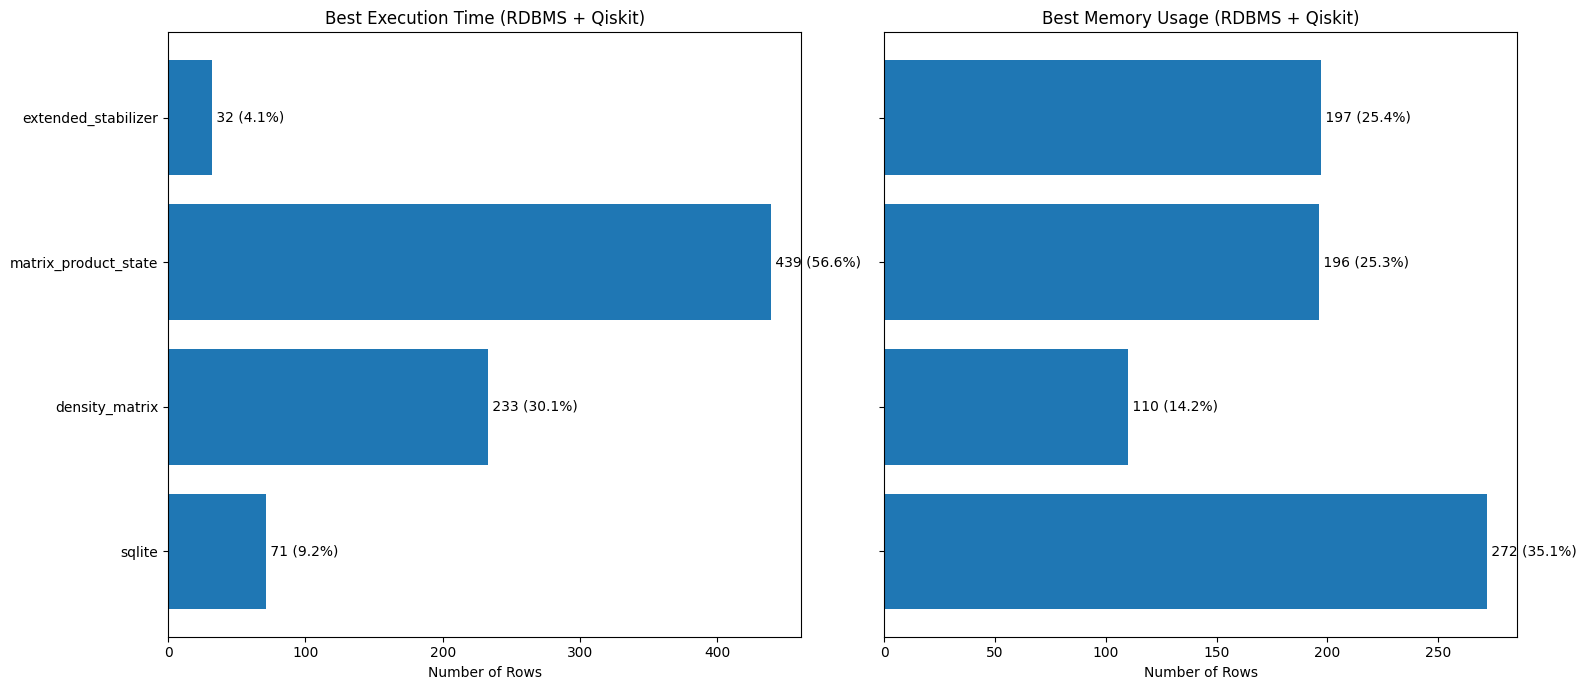

In [30]:
import matplotlib.pyplot as plt

# -------------------------------------------------
# Merge Qiskit results
# -------------------------------------------------
df_with_qiskit = df.merge(
    qiskit_df,
    on=PRIMARY_KEY,
    suffixes=("", "_qiskit")
)

# -------------------------------------------------
# Method definitions
# -------------------------------------------------
RDBMS_METHODS = METHODS

QISKIT_METHODS = [
    # "statevector_saved",
    "density_matrix",
    "matrix_product_state",
    "extended_stabilizer",
]

ALL_METHODS = RDBMS_METHODS + QISKIT_METHODS

# -------------------------------------------------
# Build column maps
# -------------------------------------------------
time_cols = {}
mem_cols = {}

# RDBMS
for m in RDBMS_METHODS:
    time_cols[m] = [c for c in df_with_qiskit.columns if c.endswith("time_s") and m in c]
    mem_cols[m]  = [c for c in df_with_qiskit.columns if c.endswith("mb") and m in c]

# Qiskit
for m in QISKIT_METHODS:
    time_cols[m] = [c for c in df_with_qiskit.columns if c.endswith("execution_time") and m in c]
    mem_cols[m]  = [c for c in df_with_qiskit.columns if c.endswith("memory_usage") and m in c]

# -------------------------------------------------
# Best method per row
# -------------------------------------------------
def best_method_per_row(row, col_map):
    values = {}
    for method, cols in col_map.items():
        if cols:
            v = row[cols].min()
            if pd.notna(v):
                values[method] = v
    return min(values, key=values.get) if values else np.nan

df_with_qiskit["best_time_method"] = df_with_qiskit.apply(
    best_method_per_row, axis=1, col_map=time_cols
)
df_with_qiskit["best_mem_method"] = df_with_qiskit.apply(
    best_method_per_row, axis=1, col_map=mem_cols
)

# -------------------------------------------------
# Count wins
# -------------------------------------------------
time_counts = (
    df_with_qiskit["best_time_method"]
    .value_counts()
    .reindex(ALL_METHODS, fill_value=0)
)

mem_counts = (
    df_with_qiskit["best_mem_method"]
    .value_counts()
    .reindex(ALL_METHODS, fill_value=0)
)

print("Best execution time counts:")
print(time_counts)
print("\nBest memory usage counts:")
print(mem_counts)

# -------------------------------------------------
# Plot 1×2 horizontal histograms with percentages
# -------------------------------------------------
time_total = time_counts.sum()
mem_total  = mem_counts.sum()

fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=True)

# ---- Execution time ----
axes[0].barh(time_counts.index, time_counts.values)
axes[0].set_title("Best Execution Time (RDBMS + Qiskit)")
axes[0].set_xlabel("Number of Rows")

for i, count in enumerate(time_counts.values):
    pct = 100 * count / time_total if time_total else 0
    axes[0].text(count, i, f" {count} ({pct:.1f}%)", va="center")

# ---- Memory ----
axes[1].barh(mem_counts.index, mem_counts.values)
axes[1].set_title("Best Memory Usage (RDBMS + Qiskit)")
axes[1].set_xlabel("Number of Rows")

for i, count in enumerate(mem_counts.values):
    pct = 100 * count / mem_total if mem_total else 0
    axes[1].text(count, i, f" {count} ({pct:.1f}%)", va="center")

plt.tight_layout()
plt.show()


Train size: 581, Test size: 194
Random Forest        accuracy = 0.593
Decision Tree        accuracy = 0.562
K-Nearest Neighbors  accuracy = 0.582
Logistic Regression  accuracy = 0.593
Linear SVM           accuracy = 0.593
XGBoost Classifier   accuracy = 0.593


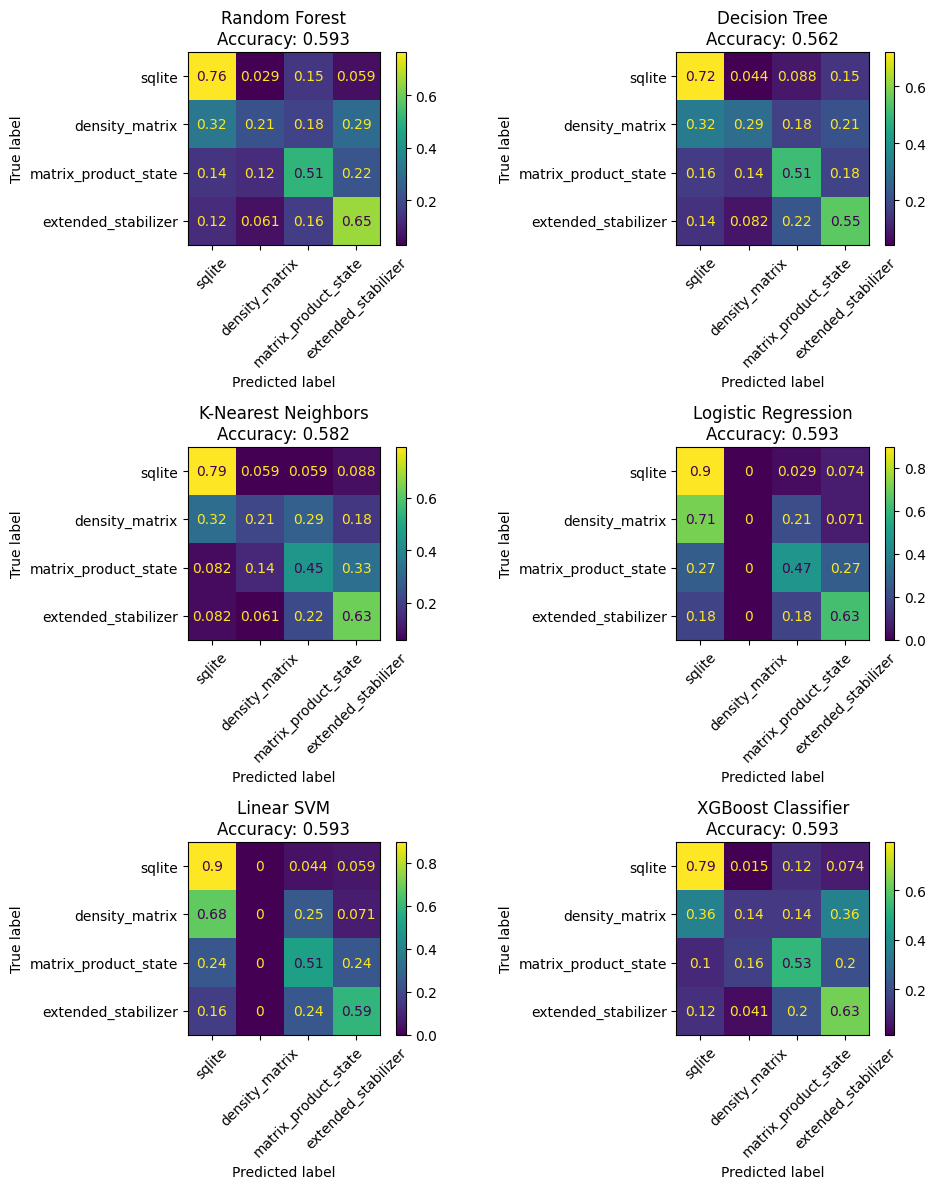

In [32]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

from utils import PlotConfusionReports

# -------------------------------------------------
# 1. Build X and y
# -------------------------------------------------
X = df_with_qiskit[FEATURES]
# y = df_with_qiskit["best_time_method"]   # string labels
y = df_with_qiskit["best_mem_method"]   # string labels


X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)
print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")

# Label encoder (shared, but only used where needed)
label_encoder = LabelEncoder()
y_train_enc = label_encoder.fit_transform(y_train)
y_test_enc  = label_encoder.transform(y_test)

# -------------------------------------------------
# 2. Define models
# -------------------------------------------------
models = {
    # ---- Native string support ----
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),

    "K-Nearest Neighbors": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", KNeighborsClassifier(n_neighbors=7))
    ]),

    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=2000))
    ]),

    "Linear SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", SVC(kernel="linear"))
    ]),

    # ---- Requires numeric labels ----
    "XGBoost Classifier": XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="multi:softmax",
        num_class=len(label_encoder.classes_),
        eval_metric="mlogloss",
        random_state=42
    )
}

# -------------------------------------------------
# 3. Train + predict
# -------------------------------------------------
model_to_y_pred = {}

for name, model in models.items():

    if name == "XGBoost Classifier":
        # numeric labels only for XGBoost
        model.fit(X_train, y_train_enc)
        y_pred_enc = model.predict(X_test)
        y_pred = label_encoder.inverse_transform(y_pred_enc)

    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    model_to_y_pred[name] = y_pred
    acc = accuracy_score(y_test, y_pred)
    print(f"{name:20s} accuracy = {acc:.3f}")

# -------------------------------------------------
# 4. Plot confusion matrices
# -------------------------------------------------
PlotConfusionReports(y_test, model_to_y_pred, ALL_METHODS)
